# Metadata integration

# Load Packages

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

sns.set(style="whitegrid")
%matplotlib inline

# Define Paths

In [ ]:
# Paths

# Paths

BASE_DIR = Path("/content/predictive-microbiology-course").resolve() #project_root
print("Current working directory:", BASE_DIR)

DATA_DIR = (BASE_DIR / "dataset").resolve()
DATA_IBDMDB = (DATA_DIR /"ibdmdb_hmp2").resolve()
PATH_results = (BASE_DIR / "results").resolve()

# DADA2
DADA2_RESULT_DIR = (PATH_results / "dada2_trunc_180").resolve()
taxa_file = DADA2_RESULT_DIR / "taxa_export" /  "taxonomy.tsv"
feature_file = DADA2_RESULT_DIR / "table_export" /  "feature-table.tsv"

# PICRUST2
PICRUST2_RESULT_DIR = (PATH_results / "picrust2_out").resolve()
ec_file = PICRUST2_RESULT_DIR / "EC_metagenome_out" / "pred_metagenome_contrib.tsv.gz"
#ko_file = PICRUST2_RESULT_DIR / "KO_metagenome_out" / "pred_metagenome_contrib.tsv.gz"
#pathways_contrib_file = PICRUST2_RESULT_DIR / "pathways_out" / "path_abun_contrib.tsv.gz"
pathways_unstrat_file = PICRUST2_RESULT_DIR / "pathways_out" / "path_abun_unstrat.tsv.gz"


# Create figures directory
FIG_PATH = BASE_DIR / "figures"
FIG_PATH.mkdir(parents=True, exist_ok=True)

# Create tables directory
TABLE_PATH = BASE_DIR / "results_tables"
TABLE_PATH.mkdir(parents=True, exist_ok=True)

# Metadata 
metadata_file = DATA_DIR / "ibdmdb_hmp2"/ "metadata" / "hmp2_metadata_2018-08-20_fixed.tsv" # "metadata.tsv"

# Metadata exploration

Now, let's explore the samples metadata.

In [50]:
# Load metadata
df_metadata = pd.read_csv(metadata_file, sep="\t")

# Print head of metadata
df_metadata.head()

,Project,External ID,sample-id,site_sub_coll,data_type,week_num,date_of_receipt,interval_days,visit_num,Research Project,...,FecalCal received at MGH:,Proteomics received at LBNL:,Stool Sample ID: Tube A (EtOH),Sample ID: Tube B (No preservative),Tube A and B received at Broad:,stool_id,smoking status,Number years smoked,Age when started smoking,How many cigarettes/cigars/etc. do you smoke per day?
0,C3001CSC1_BP,206615,C3001,C3001CSC1,biopsy_16S,2.0,NaN,NaN,1,ibdmdb,...,No,No,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
1,C3001CSC2_BP,206614,C3001,C3001CSC2,biopsy_16S,2.0,NaN,NaN,1,ibdmdb,...,No,No,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
2,C3002CSC1_BP,206617,C3002,C3002CSC1,biopsy_16S,0.0,NaN,NaN,1,ibdmdb,...,No,No,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
3,C3002CSC2_BP,206619,C3002,C3002CSC2,biopsy_16S,0.0,NaN,NaN,1,ibdmdb,...,No,No,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
4,C3002CSC3_BP,206616,C3002,C3002CSC3,biopsy_16S,0.0,NaN,NaN,1,ibdmdb,...,No,No,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN


In [51]:
print(f"Number of samples in metadata: {df_metadata.shape[0]}")
print(f"Number of unique samples in metadata: {df_metadata['External ID'].nunique()}")
print(f"Number of features in metadata: {df_metadata.shape[1]}")


Number of samples in metadata: 178
Number of unique samples in metadata: 178
Number of features in metadata: 490


## Visualize metadata completeness

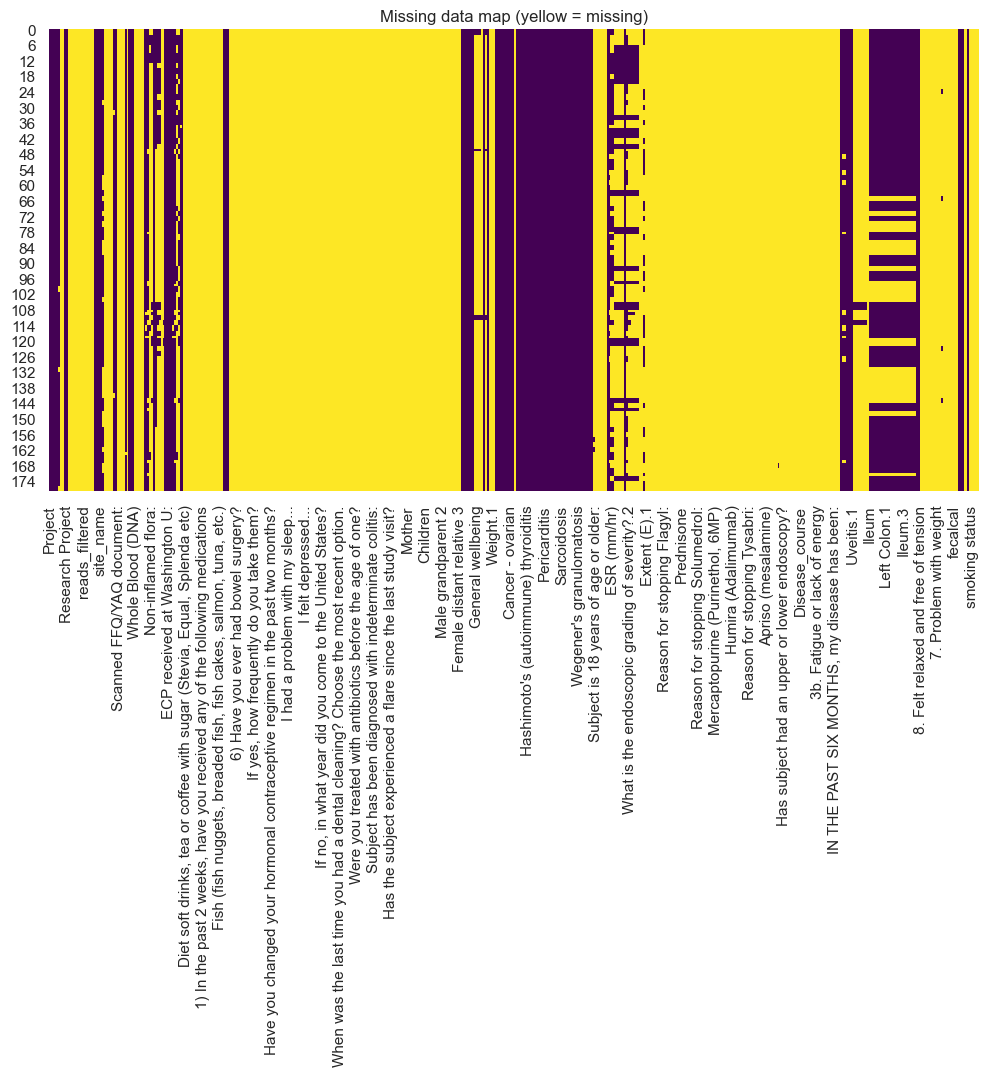

date_of_receipt                                          100.0
interval_days                                            100.0
PDO Number                                               100.0
GSSR IDs                                                 100.0
Product                                                  100.0
                                                         ...  
stool_id                                                 100.0
smoking status                                           100.0
Number years smoked                                      100.0
Age when started smoking                                 100.0
How many cigarettes/cigars/etc. do you smoke per day?    100.0
Length: 352, dtype: float64


In [52]:
# Visualize missing data across all columns

plt.figure(figsize=(12, 6))
sns.heatmap(df_metadata.isnull(), cbar=False, cmap='viridis')
plt.title("Missing data map (yellow = missing)")
plt.show()

# Get a percentage list
missing_pct = df_metadata.isnull().mean() * 100
print(missing_pct[missing_pct > 50]) # Columns with >50% missing data

## Reducing metadadata

In real-world scenarios, data is often incomplete. Before applying any machine learning algorithm, we must first identify missing values (NaNs) and decide how to handle them—such as removing them or estimating them through interpolation or other imputation methods.

# Keep features with complete data

We can do this with boolean indexing

In [53]:
full_data_features= missing_pct[missing_pct == 0].index.tolist()

print(f"Found {len(full_data_features)} features with 100% data completion:")
print(full_data_features)

Found 98 features with 100% data completion:
['Project', 'External ID', 'sample-id', 'site_sub_coll', 'data_type', 'visit_num', 'Research Project', 'IntervalName', 'IntervalSequence', 'ProjectSpecificID', 'site_name', 'Occupation', 'Whole blood received at Broad:', 'Serum tube #1 received at CSMC:', 'Serum tubes #2-4 received at MGH:', 'Number of flora tubes collected:', 'Have samples been sent for histopathology?', 'FLora received at MGH:', 'RNA/DNA received at Broad:', 'ECP received at Washington U:', 'Number of DNA/RNA tubes collected:', 'diagnosis', 'Antibiotics', 'Chemotherapy', 'Immunosuppressants (e.g. oral corticosteroids)', 'Uveitis', 'Erythema nodosum', 'Aphthous ulcers', 'Pyoderma gangrenosum', 'Anal fissure', 'New fistula', 'Abscess', 'Arthralgia', 'Hispanic or Latino Origin', 'Cancer - breast', 'Cancer - cholangiocarcinoma', 'Cancer - colon or rectum', "Cancer - Hodgkin's lymphoma", 'Cancer - liver', 'Cancer - lung', 'Cancer - lymphoma (not otherwise specified)', "Cancer -

<Axes: >

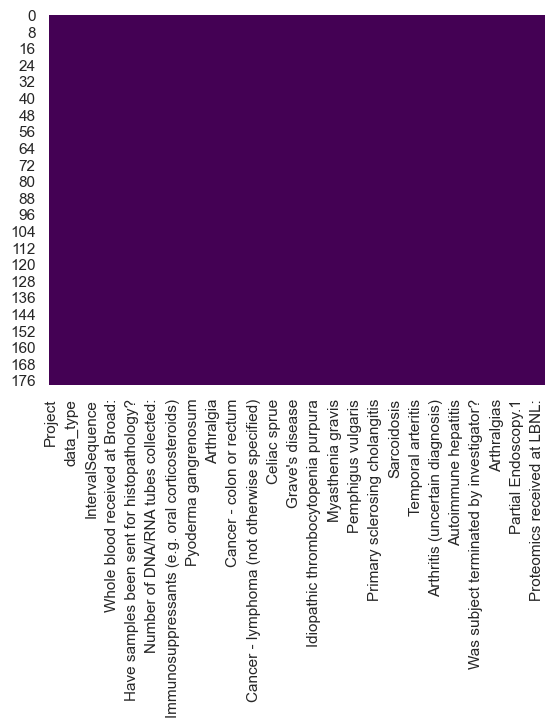

In [54]:
# Keep only features with complete data
df_metadata_complete = df_metadata[full_data_features]

# Check that we have no missing data (We should not see any yellow here)
sns.heatmap(df_metadata_complete.isnull(), cbar=False, cmap='viridis')

In [55]:
# Some variables are constant or do not have any biological meaning, so we can drop them (e.g., data_type)
print(df_metadata_complete["data_type"])
print("Number of unique values:", df_metadata_complete["data_type"].nunique())

0      biopsy_16S
1      biopsy_16S
2      biopsy_16S
3      biopsy_16S
4      biopsy_16S
          ...    
173    biopsy_16S
174    biopsy_16S
175    biopsy_16S
176    biopsy_16S
177    biopsy_16S
Name: data_type, Length: 178, dtype: object
Number of unique values: 1


In [ ]:
# Remove constant or biologically irrelevant features

unique_counts = df_metadata_complete.nunique()
to_drop = unique_counts[unique_counts <= 1].index
to_drop = to_drop.tolist()
more_to_drop= ["Project", "site_sub_coll"]
to_drop.extend(more_to_drop) # We know this one is not useful
print(f"Found {len(to_drop)} constant features:")
print(to_drop)

Found 76 constant features:
['data_type', 'Research Project', 'Whole blood received at Broad:', 'Serum tube #1 received at CSMC:', 'Serum tubes #2-4 received at MGH:', 'FLora received at MGH:', 'RNA/DNA received at Broad:', 'Antibiotics', 'Chemotherapy', 'Immunosuppressants (e.g. oral corticosteroids)', 'Uveitis', 'Erythema nodosum', 'Pyoderma gangrenosum', 'Anal fissure', 'New fistula', 'Arthralgia', 'Cancer - breast', 'Cancer - cholangiocarcinoma', 'Cancer - colon or rectum', "Cancer - Hodgkin's lymphoma", 'Cancer - liver', 'Cancer - lung', 'Cancer - lymphoma (not otherwise specified)', "Cancer - Non-Hodkin's lymphoma", 'Cancer - ovarian', 'Cancer - prostate', 'Celiac sprue', 'Chronic bronchitis', 'Dermatitis herpetiformis', 'Familial Mediterranean fever', "Grave's disease", 'Guillian-Barre Syndrome', "Hashimoto's (autoimmune) thyroiditis", 'Idiopathic pulmonary fibrosis', 'Idiopathic thrombocytopenia purpura', 'Irritable bowel syndrome', 'Alopecia areata', 'Multiple sclerosis', 'Mya

Although we drop features such as 'Cancer - Hodgkin's lymphoma', 'Cancer - liver', 'Cancer - lung', etc., these features are not biologically meaningful since there is no variability among samples. Thus, they do not add any information to the analysis. 

In [87]:
# We make a new df with only the features with information
df_metadata_complete_variable = df_metadata_complete.drop(columns=to_drop)

# Print remaining columns
print(f"Remaining columns after dropping constant features: {len(df_metadata_complete_variable.columns)}")


Remaining columns after dropping constant features: 22


# Merge reduced metadata with qiime2 and picrust2 data

In [58]:
#Load picrust2 tables

# Pathways relative abundance (functional profiles)
pathways_rel = pd.read_csv(TABLE_PATH / "pathways_unstrat_relative.csv", sep=",", index_col=0)

#Genus relative abundance (taxonomic profiles)
genus_rel = pd.read_csv(TABLE_PATH / "genus_relative_abundance.csv", sep=",", index_col=0)


In [59]:
# We need rows as samples and columns as features for machine learning, so we transpose the tables

pathways_ml = pathways_rel#.T
genus_ml = genus_rel.T

In [ ]:
df_metadata_complete_variable = df_metadata_complete_variable.set_index("External ID")
df_metadata_complete_variable.index = df_metadata_complete_variable.index.astype(str)

df_metadata_complete_variable.to_csv(TABLE_PATH / "df_meta_for_ml.csv", index=True)
print('Metadata and saved!')

Metadata and saved!


In [61]:
pathways_ml.index = pathways_ml.index.astype(str)

In [62]:
common = pathways_ml.index.intersection(df_metadata_complete_variable.index).intersection(genus_ml.index)   

print("Common samples:", len(common))
print(list(common[:5]))

Common samples: 165
['206534', '206536', '206538', '206547', '206548']


In [ ]:
# Merge and save the merged table for machine learning
df_merged_biology = pathways_ml.loc[common].merge(
        genus_ml.loc[common],
        left_index=True,
        right_index=True
    )
print(df_merged_biology.shape)
df_merged_biology.to_csv(TABLE_PATH / "df_micro_for_ml.csv", index=True)
print('Biology data merged and saved!')

(165, 913)
Biology data merged and saved!


In [ ]:
# Merge and save the merged table for machine learning
df_merged_all = pathways_ml.loc[common].merge(
    df_metadata_complete_variable.loc[common],
    left_index=True,
    right_index=True
).merge(
    genus_ml.loc[common],
    left_index=True,
    right_index=True
)
print(df_merged_all.shape)
df_merged_all.to_csv(TABLE_PATH / "df_micro_meta_for_ml.csv", index=True)
print('Biology & metadata merged and saved!')

(165, 936)
Biology & metadata merged and saved!


# Descriptive statistics of metadata 

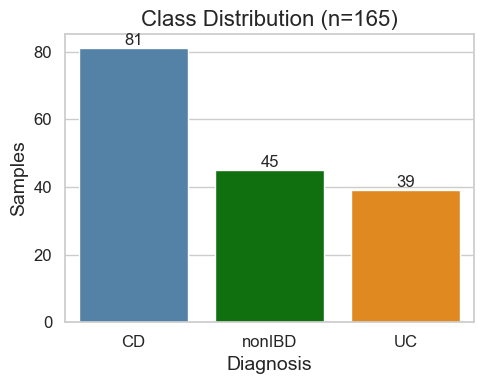

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

counts = df_merged_all['diagnosis'].value_counts()

# Define colors per class
palette = {
    "nonIBD": "green",
    "CD": "steelblue",
    "UC": "darkorange"
}

plt.figure(figsize=(5,4))

sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=[palette[c] for c in counts.index]
)

# Add labels on top
for i, v in enumerate(counts.values):
    plt.text(i, v + 1, str(v), ha='center')

plt.title(f"Class Distribution (n={df_merged_all.shape[0]})", fontsize=16)
plt.xlabel("Diagnosis", fontsize=14)
plt.ylabel("Samples", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(np.arange(0,100,20), fontsize=12)

plt.tight_layout()
plt.savefig(FIG_PATH / "class_distribution.png", dpi=300)
plt.show()

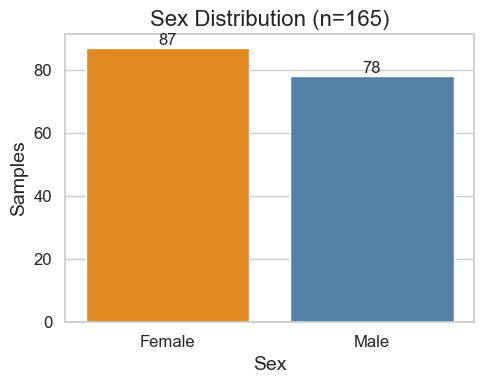

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

counts = df_merged_all['sex'].value_counts()

# Define colors per class
palette = {
    #"": "green",
    "Male": "steelblue",
    "Female": "darkorange"
}

plt.figure(figsize=(5,4))

sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=[palette[c] for c in counts.index]
)

# Add labels on top
for i, v in enumerate(counts.values):
    plt.text(i, v + 1, str(v), ha='center')

plt.title(f"Sex Distribution (n={df_merged_all.shape[0]})", fontsize=16)
plt.xlabel("Sex", fontsize=14)
plt.ylabel("Samples", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(np.arange(0,100,20), fontsize=12)

plt.tight_layout()
plt.savefig(FIG_PATH / "sex_distribution.png", dpi=300)
plt.show()

# Pathways PCA

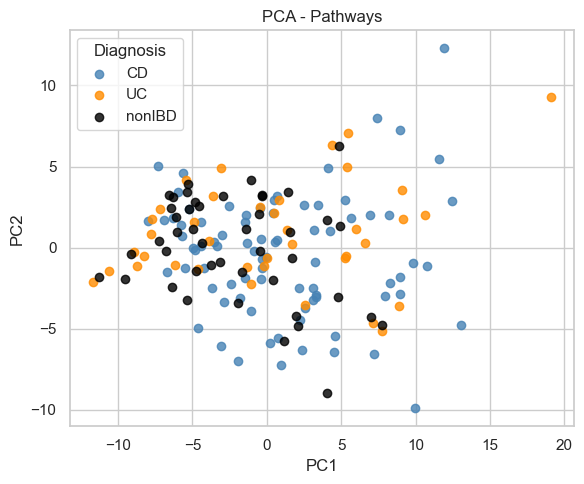

In [65]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# data
X = np.log10(pathways_ml + 1e-6)

# PCA
coords = PCA(n_components=2).fit_transform(X)

# labels
labels = df_metadata_complete_variable.loc[X.index, "diagnosis"]

# color mapping
unique_labels = labels.unique()
colors = dict(zip(unique_labels, ["steelblue", "darkorange", "black"]))

plt.figure(figsize=(6,5))

for lab in unique_labels:
    idx = labels == lab
    plt.scatter(coords[idx, 0], coords[idx, 1],
                label=lab,
                color=colors[lab],
                alpha=0.8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Pathways")
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.show()

# Genus PCA

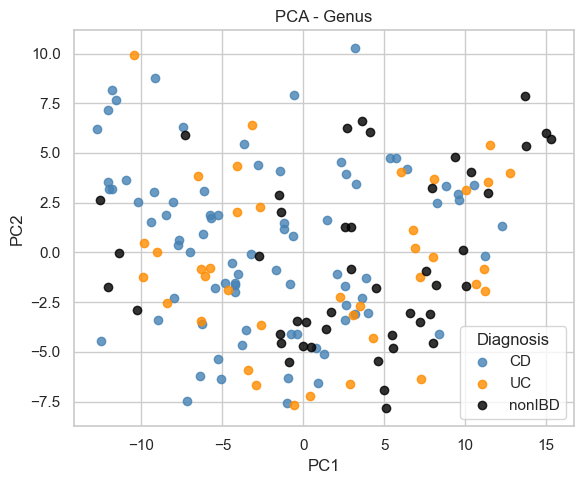

In [66]:
X = np.log10(genus_ml + 1e-6)

coords = PCA(n_components=2).fit_transform(X)

labels = df_metadata_complete_variable.loc[X.index, "diagnosis"]

unique_labels = labels.unique()
colors = dict(zip(unique_labels, ["steelblue", "darkorange", "black"]))

plt.figure(figsize=(6,5))

for lab in unique_labels:
    idx = labels == lab
    plt.scatter(coords[idx, 0], coords[idx, 1],
                label=lab,
                color=colors[lab],
                alpha=0.8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Genus")
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.show()

# All features PCA

In [ ]:


X = np.log10(df_merged_final + 1e-6)

coords = PCA(n_components=2).fit_transform(X)

labels = df_metadata_complete_variable.loc[X.index, "diagnosis"]

unique_labels = labels.unique()
colors = dict(zip(unique_labels, ["steelblue", "darkorange", "black"]))

plt.figure(figsize=(6,5))

for lab in unique_labels:
    idx = labels == lab
    plt.scatter(coords[idx, 0], coords[idx, 1],
                label=lab,
                color=colors[lab],
                alpha=0.8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Genus")
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.show()